Dataset Loading

In [1]:
DATA_PATH = "/kaggle/input/modelnet40-princeton-3d-object-dataset"

In [2]:
!pip install open3d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 69.5 MB/s eta 0:00:00


In [3]:
# Import libraries
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.functional import normalize

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from tqdm.notebook import tqdm
from scipy.spatial.distance import pdist, squareform


import random
import warnings
warnings.filterwarnings('ignore')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [4]:
DATA_PATH = "/kaggle/input/modelnet40-princeton-3d-object-dataset"
# The actual data is inside the 'ModelNet40' subdirectory
MODELNET_PATH = os.path.join(DATA_PATH, 'ModelNet40')
categories = sorted(os.listdir(MODELNET_PATH))

# Compute counts for each category
category_counts = {}
for cat in categories:
    train_folder = os.path.join(MODELNET_PATH, cat, 'train')
    test_folder = os.path.join(MODELNET_PATH, cat, 'test')
    train_count = len([f for f in os.listdir(train_folder) if f.endswith('.off')])
    test_count = len([f for f in os.listdir(test_folder) if f.endswith('.off')])
    total = train_count + test_count
    balance_ratio = min(train_count / test_count, test_count / train_count) if test_count > 0 and train_count > 0 else 0
    category_counts[cat] = {
        'train': train_count,
        'test': test_count,
        'total': total,
        'balance_ratio': balance_ratio
    }

In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(categories)
print(f"Total Categories: {len(categories)}")
print(f"Example Categories: {categories}")

Total Categories: 40
Example Categories: ['airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair', 'cone', 'cup', 'curtain', 'desk', 'door', 'dresser', 'flower_pot', 'glass_box', 'guitar', 'keyboard', 'lamp', 'laptop', 'mantel', 'monitor', 'night_stand', 'person', 'piano', 'plant', 'radio', 'range_hood', 'sink', 'sofa', 'stairs', 'stool', 'table', 'tent', 'toilet', 'tv_stand', 'vase', 'wardrobe', 'xbox']


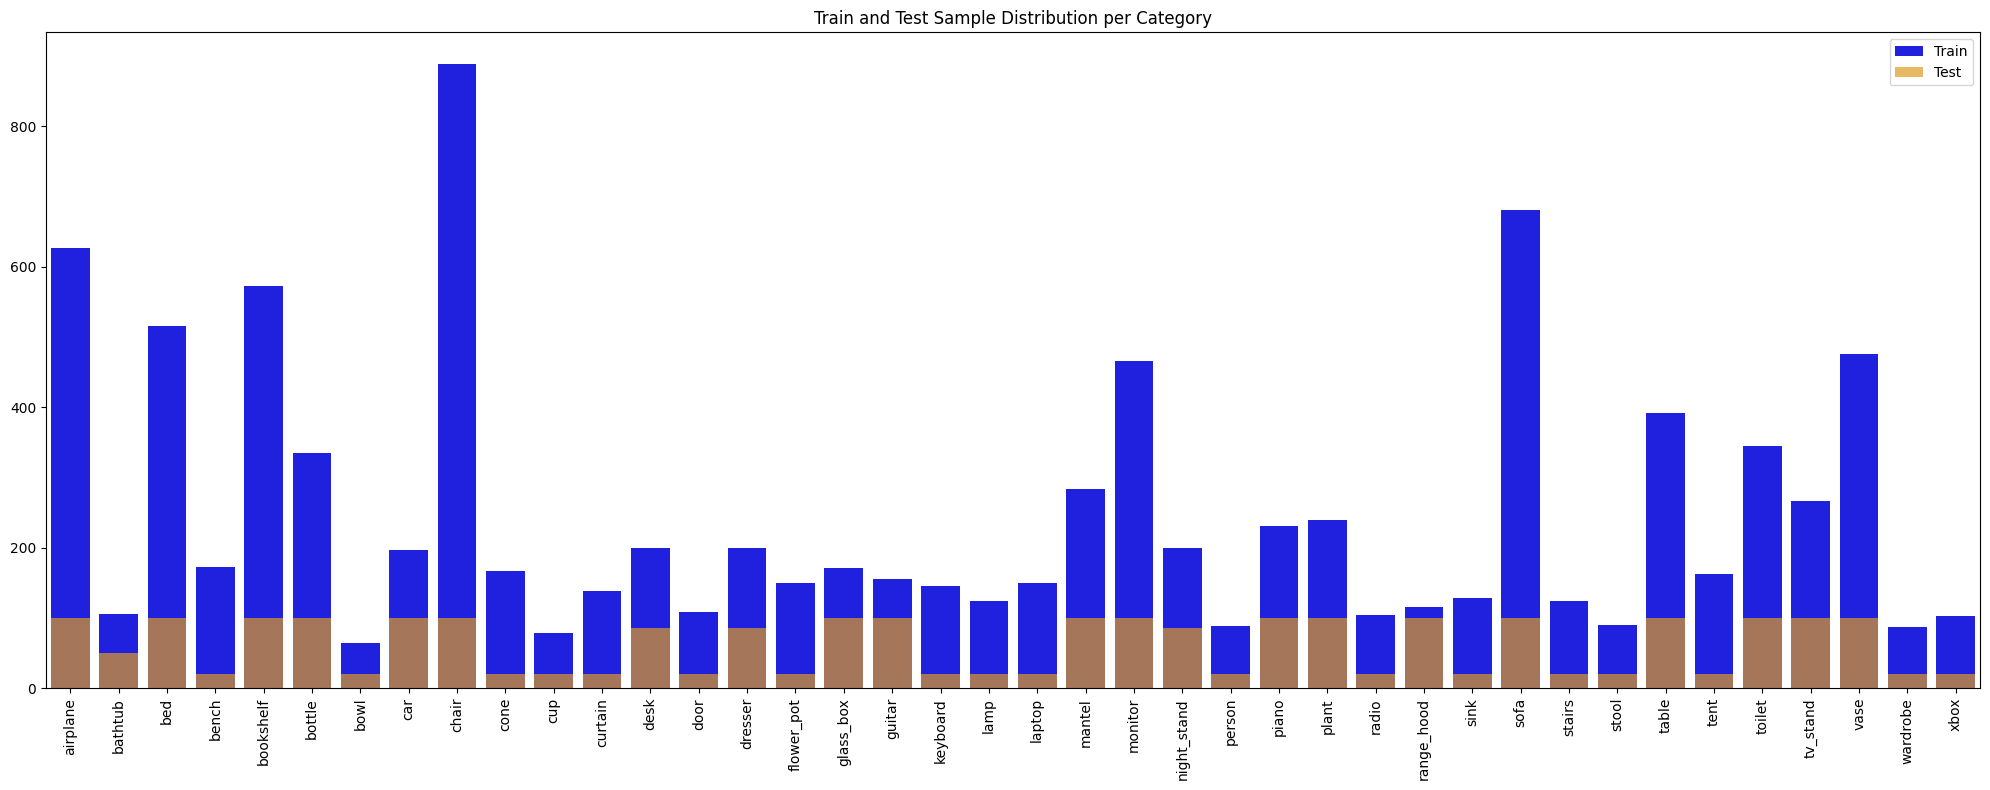

In [6]:
# The actual data is inside the 'ModelNet40' subdirectory
MODELNET_PATH = os.path.join(DATA_PATH, 'ModelNet40')

category_counts = {}
for cat in categories:
    train_path = os.path.join(MODELNET_PATH, cat, "train")
    test_path = os.path.join(MODELNET_PATH, cat, "test")
    # Check if the directories exist before listing files
    if os.path.exists(train_path) and os.path.exists(test_path):
        category_counts[cat] = {
            "train": len(os.listdir(train_path)),
            "test": len(os.listdir(test_path))
        }
    else:
        print(f"Warning: train or test directory not found for category: {cat}")
        category_counts[cat] = {
            "train": 0,
            "test": 0
        }


# Filter out categories with no train or test data for plotting
plot_categories = [cat for cat in categories if category_counts[cat]["train"] > 0 or category_counts[cat]["test"] > 0]
train_counts = [category_counts[cat]["train"] for cat in plot_categories]
test_counts = [category_counts[cat]["test"] for cat in plot_categories]

plt.figure(figsize=(20, 8)) # Increase figure size for better readability
sns.barplot(x=plot_categories, y=train_counts, color="blue", label="Train")
sns.barplot(x=plot_categories, y=test_counts, color="orange", label="Test", alpha=0.7)
plt.xticks(rotation=90)
plt.title("Train and Test Sample Distribution per Category")
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

# Workplan / Clustering Pipeline:
To classify 3D point clouds from the ModelNet40 dataset using a self-supervised learning approach with Torque Clustering, we integrate the Torque Clustering Implementation into a deep clustering pipeline. This leverages a PointNet backbone for feature extraction from point clouds, applies Torque Clustering on the extracted features to generate pseudo-labels (treating the algorithm as a means to discover structure autonomously), and refines the features via contrastive learning on those pseudo-labels. Finally, a linear probe is used for supervised evaluation on the true labels.

# Key adaptations:
Preprocessing: Loads .off files using Open3D, sample to 1024 points, normalizes to unit sphere (as in the original notebook).
Feature Extraction: Use PointNet to get global features per object (256D).
Torque Clustering: Uses the density-based mass variant (suitable for varying point cloud densities). We set n_clusters=40 for ModelNet40's 40 classes in self-supervised mode, but paper's original TC is parameter-free—future work could adapt the auto-detection via TGap.
Self-Supervised Training: Uses pseudo-labels from Torque Clustering for contrastive loss (e.g., NT-Xent) to refine features.
Evaluation: Linear regression probe on frozen features; computes accuracy and ARI against true labels.

# The Density-based mass variant of the Torque Clustering algorithm

In [7]:
def calculate_mass(data, method='uniform', k=5):
    """Calculates the "mass" of each data point."""
    n_samples = data.shape[0]

    if method == 'uniform':
        return np.ones(n_samples)
    elif method == 'density':
        distances = squareform(pdist(data, 'euclidean'))
        distances.sort(axis=1)
        knn_distances = distances[:, 1:k+1]  # k nearest neighbors (excluding self)
        local_density = 1 / (np.mean(knn_distances, axis=1) + 1e-9)
        return local_density / np.sum(local_density)  # Normalize
    elif method == 'feature_sum':
        return np.sum(np.abs(data), axis=1) / np.sum(np.abs(data))
    elif method == 'feature_variance':
        return np.var(data, axis = 1) / np.sum(np.var(data, axis = 1))
    else:
        raise ValueError("Invalid mass calculation method.")

def calculate_distance_matrix(data):
    """Compute the pairwise Euclidean distance matrix."""
    return squareform(pdist(data, 'euclidean'))

def calculate_torque(data, masses, distances, k_neighbors=None):
    """Calculates the weighted average torque on each data point."""
    n_samples = data.shape[0]
    torques = np.zeros_like(data, dtype=float)

    for i in range(n_samples):
        if k_neighbors is None:  # Use all points
            neighbors = np.arange(n_samples)
        else:  # Use k-nearest neighbors
            distances_from_i = distances[i, :]
            neighbor_indices = np.argsort(distances_from_i)[1:k_neighbors + 1] # Exclude self
            neighbors = neighbor_indices

        total_weight = 0.0
        for j in neighbors:
            if i != j:
                direction_vector = data[j] - data[i]
                distance = distances[i, j]
                weight = masses[j] / (distance**2 + 1e-9)  # Weighted by mass and inverse square distance
                torques[i] += weight * direction_vector
                total_weight += weight

        if total_weight > 0:
            torques[i] /= total_weight  # Normalize by total weight (weighted average)

    return torques

def torque_clustering(data, mass_method='uniform', learning_rate=0.01, max_iterations=100,
                      tolerance=1e-4, k_neighbors=None, visualize_iterations=False, k_density=5, n_clusters=40):
    """Performs Torque Clustering. Adapted for fixed n_clusters=40 for ModelNet40."""
    n_samples, n_features = data.shape
    masses = calculate_mass(data, method=mass_method, k=k_density)
    data_copy = data.copy().astype(float)
    distances = calculate_distance_matrix(data_copy)

    if visualize_iterations:
        plt.figure(figsize=(6, 6))
        plt.ion()  # Turn on interactive mode for plotting

    for iteration in range(max_iterations):
        torques = calculate_torque(data_copy, masses, distances, k_neighbors=k_neighbors)
        data_copy += learning_rate * torques

        if visualize_iterations:
            plt.clf()  # Clear the previous plot
            plt.scatter(data_copy[:, 0], data_copy[:, 1], c='blue', alpha=0.5)
            plt.title(f"Iteration: {iteration + 1}")
            plt.draw()
            plt.pause(0.1)  # Pause to show the plot

        # Convergence check (average change in position)
        if iteration > 0:
            avg_change = np.linalg.norm(data_copy - previous_positions) / n_samples
            if avg_change < tolerance:
                print(f"Converged after {iteration} iterations.")
                break
        previous_positions = data_copy.copy()

    if visualize_iterations:
        plt.ioff()  # Turn off interactive mode
        plt.show()  # Keep the final plot displayed

    # Use KMeans for final clustering (set to 40 for ModelNet40)
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto')
    cluster_labels = kmeans.fit_predict(data_copy)
    return cluster_labels, data_copy

In [8]:
class ModelNetDataset(Dataset):
    def __init__(self, root, split='train', num_points=1024):
        self.data = []
        self.labels = []
        self.num_points = num_points
        categories = sorted(os.listdir(root))
        self.num_classes = len(categories)
        label_map = {cat: idx for idx, cat in enumerate(categories)}

        for cat in categories:
            folder = os.path.join(root, cat, split)
            for file in os.listdir(folder):
                if file.endswith('.off'):
                    file_path = os.path.join(folder, file)

                    # Read .off file into memory
                    with open(file_path, 'r') as f:
                        lines = f.readlines()

                    # Fix compact headers (e.g., "OFF1743 1329 0")
                    if lines[0].strip() != "OFF":
                        header = lines[0].strip()[3:]
                        lines[0] = "OFF\n"
                        lines.insert(1, header + "\n")

                    # Parse vertices
                    n_verts, n_faces, _ = map(int, lines[1].split())
                    verts = np.array(
                        [[float(v) for v in line.split()] for line in lines[2:2+n_verts]]
                    )

                    points = verts

                    # Normalize to unit sphere
                    centroid = np.mean(points, axis=0)
                    points -= centroid
                    max_dist = np.max(np.sqrt(np.sum(points**2, axis=1)))
                    points /= max_dist

                    # Ensure fixed number of points
                    if points.shape[0] > num_points:
                        idx = np.random.choice(points.shape[0], num_points, replace=False)
                        points = points[idx, :]
                    elif points.shape[0] < num_points:
                        idx = np.random.choice(points.shape[0], num_points - points.shape[0], replace=True)
                        extra_points = points[idx, :]
                        points = np.vstack([points, extra_points])

                    self.data.append(points.astype(np.float32))
                    self.labels.append(label_map[cat])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx]), torch.tensor(self.labels[idx])



#  1. Dataset Fixes
# OFF file handling: ModelNet40 .off files sometimes had compact headers (OFF1743 1329 0).
# → Added in-memory header correction so Open3D can read them.
# Normalization stability: Prevented division by zero when normalizing point clouds.
# Fixed number of points: Randomly sampled/padded so each cloud = [1024, 3] → no DataLoader stack errors.


# Simple PointNet for Feature Extraction

In [9]:
class PointNet(nn.Module):
    def __init__(self, feature_dim=256):
        super().__init__()
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, feature_dim, 1)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(feature_dim)

        self.output_dim = feature_dim  # expose dimension

    def forward(self, x):
        x = x.transpose(2, 1)  # (B, 3, N)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))    # no ReLU on final layer
        x = torch.max(x, 2)[0]         # global max pooling
        return x


# 2. Model Fixes (PointNet)
# Original PointNet had ReLU after final BatchNorm → caused collapsed/NaN embeddings.
# Fixed by removing final ReLU → features became stable, with healthy variance.
# Exposed self.output_dim so warm-up classifier could auto-detect embedding size.


# Contrastive loss (simplified NT-Xent)

In [10]:
def contrastive_loss(features, labels, temperature=0.5):
    features = normalize(features, dim=1)
    similarity = torch.mm(features, features.t()) / temperature
    mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
    mask.fill_diagonal_(0)
    pos = torch.exp(similarity) * mask
    neg = torch.exp(similarity) * (1 - mask)
    loss = -torch.log(pos.sum(1) / (neg.sum(1) + pos.sum(1) + 1e-9))
    return loss.mean()

# Main Pipeline

In [11]:
data_path = '/kaggle/input/modelnet40-princeton-3d-object-dataset/ModelNet40'
train_dataset = ModelNetDataset(data_path, 'train')
test_dataset = ModelNetDataset(data_path, 'test')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

model = PointNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training and Evaluation

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch.optim as optim

# === Stable Contrastive Loss ===
def contrastive_loss(features, labels, temperature=0.5, eps=1e-8):
    features = F.normalize(features, dim=1)
    sim_matrix = torch.matmul(features, features.T) / temperature
    sim_matrix = torch.clamp(sim_matrix, min=-1+eps, max=1-eps)

    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(features.device)
    mask.fill_diagonal_(0)

    logits = F.log_softmax(sim_matrix, dim=1)
    numerator = (mask * logits).sum(1)
    denominator = mask.sum(1).clamp(min=1)

    loss = -numerator / denominator
    return loss.mean()


# === Phase 1: Warm-up with supervised classification ===
print("===== Warm-up Phase =====")

device = next(model.parameters()).device

# 🔎 Auto-detect embedding dimension
dummy_points, _ = next(iter(train_loader))
with torch.no_grad():
    dummy_features = model(dummy_points.to(device))
embed_dim = dummy_features.shape[1]
print(f"[INFO] Detected embedding dimension = {embed_dim}")

# Temporary classifier head
linear_head = nn.Linear(embed_dim, 40).to(device)
criterion = nn.CrossEntropyLoss()
warmup_optimizer = optim.Adam(
    list(model.parameters()) + list(linear_head.parameters()),
    lr=0.001, weight_decay=1e-4
)

# Warm-up training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for points, labels in train_loader:
        points, labels = points.to(device), labels.to(device)
        warmup_optimizer.zero_grad()
        feats = model(points)
        preds = linear_head(feats)
        loss = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        warmup_optimizer.step()
        total_loss += loss.item()
    print(f"[Warm-up] Epoch {epoch+1}, CE Loss = {total_loss/len(train_loader):.4f}")


# === Phase 2: Main training with torque clustering + contrastive loss ===
print("===== Contrastive Phase =====")

for epoch in range(10):
    model.train()
    features_list, true_labels_list = [], []

    # Pass 1: extract embeddings
    for points, true_labels in train_loader:
        points = points.to(device)
        features = model(points)
        features = F.normalize(features, dim=1)
        features_list.append(features.detach().cpu().numpy())
        true_labels_list.append(true_labels.cpu().numpy())

    all_features = np.concatenate(features_list)
    all_true_labels = np.concatenate(true_labels_list)

    all_features = np.nan_to_num(all_features, nan=0.0, posinf=1.0, neginf=-1.0)
    print(f"[DEBUG] Epoch {epoch+1}: feature mean {all_features.mean():.4f}, std {all_features.std():.4f}")

    pseudo_labels, _ = torque_clustering(
        all_features,
        mass_method='density',
        k_neighbors=10,
        k_density=10,
        n_clusters=40
    )

    # Pass 2: refine with contrastive loss
    for i, (points, _) in enumerate(train_loader):
        points = points.to(device)
        optimizer.zero_grad()
        features = model(points)
        features = F.normalize(features, dim=1)

        labels = torch.tensor(
            pseudo_labels[i*len(points):(i+1)*len(points)]
        ).to(device)

        loss = contrastive_loss(features, labels)

        if torch.isnan(loss):
            print(f"Skipping batch {i} due to NaN loss")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    print(f"[Contrastive] Epoch {epoch+1}: Loss = {loss.item():.4f}")


#  3. Training Loop Fixes
# Warm-up phase: Trained with real labels + linear head before self-supervised stage → embeddings no longer collapsed to zero.
# Contrastive phase:
# Normalized embeddings (F.normalize) for stability.
# Cleaned NaN/Inf from feature arrays (np.nan_to_num).
# Added gradient clipping (clip_grad_norm_) to avoid exploding updates.
# Improved pseudo-label slicing (i*len(points):(i+1)*len(points) batch indexing).
# Rewrote contrastive_loss to be numerically stable (log_softmax, clamping, eps).


===== Warm-up Phase =====
[INFO] Detected embedding dimension = 256
[Warm-up] Epoch 1, CE Loss = 1.6841
[Warm-up] Epoch 2, CE Loss = 1.1361
[Warm-up] Epoch 3, CE Loss = 0.9853
[Warm-up] Epoch 4, CE Loss = 0.8951
[Warm-up] Epoch 5, CE Loss = 0.8303
[Warm-up] Epoch 6, CE Loss = 0.7895
[Warm-up] Epoch 7, CE Loss = 0.7506
[Warm-up] Epoch 8, CE Loss = 0.7141
[Warm-up] Epoch 9, CE Loss = 0.6834
[Warm-up] Epoch 10, CE Loss = 0.6581
===== Contrastive Phase =====
[DEBUG] Epoch 1: feature mean 0.0529, std 0.0332
Converged after 1 iterations.
[Contrastive] Epoch 1: Loss = 1.5497
[DEBUG] Epoch 2: feature mean 0.0553, std 0.0290
Converged after 1 iterations.
[Contrastive] Epoch 2: Loss = 0.7749
[DEBUG] Epoch 3: feature mean 0.0570, std 0.0256
Converged after 1 iterations.
[Contrastive] Epoch 3: Loss = 0.6199
[DEBUG] Epoch 4: feature mean 0.0579, std 0.0235
Converged after 1 iterations.
[Contrastive] Epoch 4: Loss = 2.1696
[DEBUG] Epoch 5: feature mean 0.0583, std 0.0226
Converged after 1 iterations

# Evaluation: Extract test features, Linear Probe

In [13]:
model.eval()
train_features = []
train_labels = []
for points, labels in train_loader:
    with torch.no_grad():
        feats = model(points).cpu().numpy()
    train_features.append(feats)
    train_labels.append(labels.numpy())
train_features = np.concatenate(train_features)
train_labels = np.concatenate(train_labels)

test_features = []
test_labels = []
for points, labels in test_loader:
    with torch.no_grad():
        feats = model(points).cpu().numpy()
    test_features.append(feats)
    test_labels.append(labels.numpy())
test_features = np.concatenate(test_features)
test_labels = np.concatenate(test_labels)

# Linear probe
clf = LogisticRegression(max_iter=1000)
clf.fit(train_features, train_labels)
pred = clf.predict(test_features)
acc = accuracy_score(test_labels, pred)
print(f'Classification Accuracy: {acc * 100:.2f}%')

# Clustering quality (ARI on train pseudo vs True)
ari = adjusted_rand_score(all_true_labels, pseudo_labels)
print(f'Train ARI (pseudo vs true): {ari:.4f}')

nmi = normalized_mutual_info_score(train_labels, pseudo_labels)
print(f'Train NMI (pseudo vs true): {nmi:.4f}')

Classification Accuracy: 78.77%
Train ARI (pseudo vs true): 0.2394
Train NMI (pseudo vs true): 0.0242


## Training with the Top 20 Highest Entry Holding Classes

Selected Top 20 Categories (balanced and high samples): 20
Categories: ['chair', 'sofa', 'airplane', 'bookshelf', 'bed', 'vase', 'monitor', 'table', 'toilet', 'bottle']
chair: train=889, test=100, total=989, balance_ratio=0.11
sofa: train=680, test=100, total=780, balance_ratio=0.15
airplane: train=626, test=100, total=726, balance_ratio=0.16
bookshelf: train=572, test=100, total=672, balance_ratio=0.17
bed: train=515, test=100, total=615, balance_ratio=0.19
vase: train=475, test=100, total=575, balance_ratio=0.21
monitor: train=465, test=100, total=565, balance_ratio=0.22
table: train=392, test=100, total=492, balance_ratio=0.26
toilet: train=344, test=100, total=444, balance_ratio=0.29
bottle: train=335, test=100, total=435, balance_ratio=0.30
mantel: train=284, test=100, total=384, balance_ratio=0.35
tv_stand: train=267, test=100, total=367, balance_ratio=0.37
plant: train=240, test=100, total=340, balance_ratio=0.42
piano: train=231, test=100, total=331, balance_ratio=0.43
car: tra

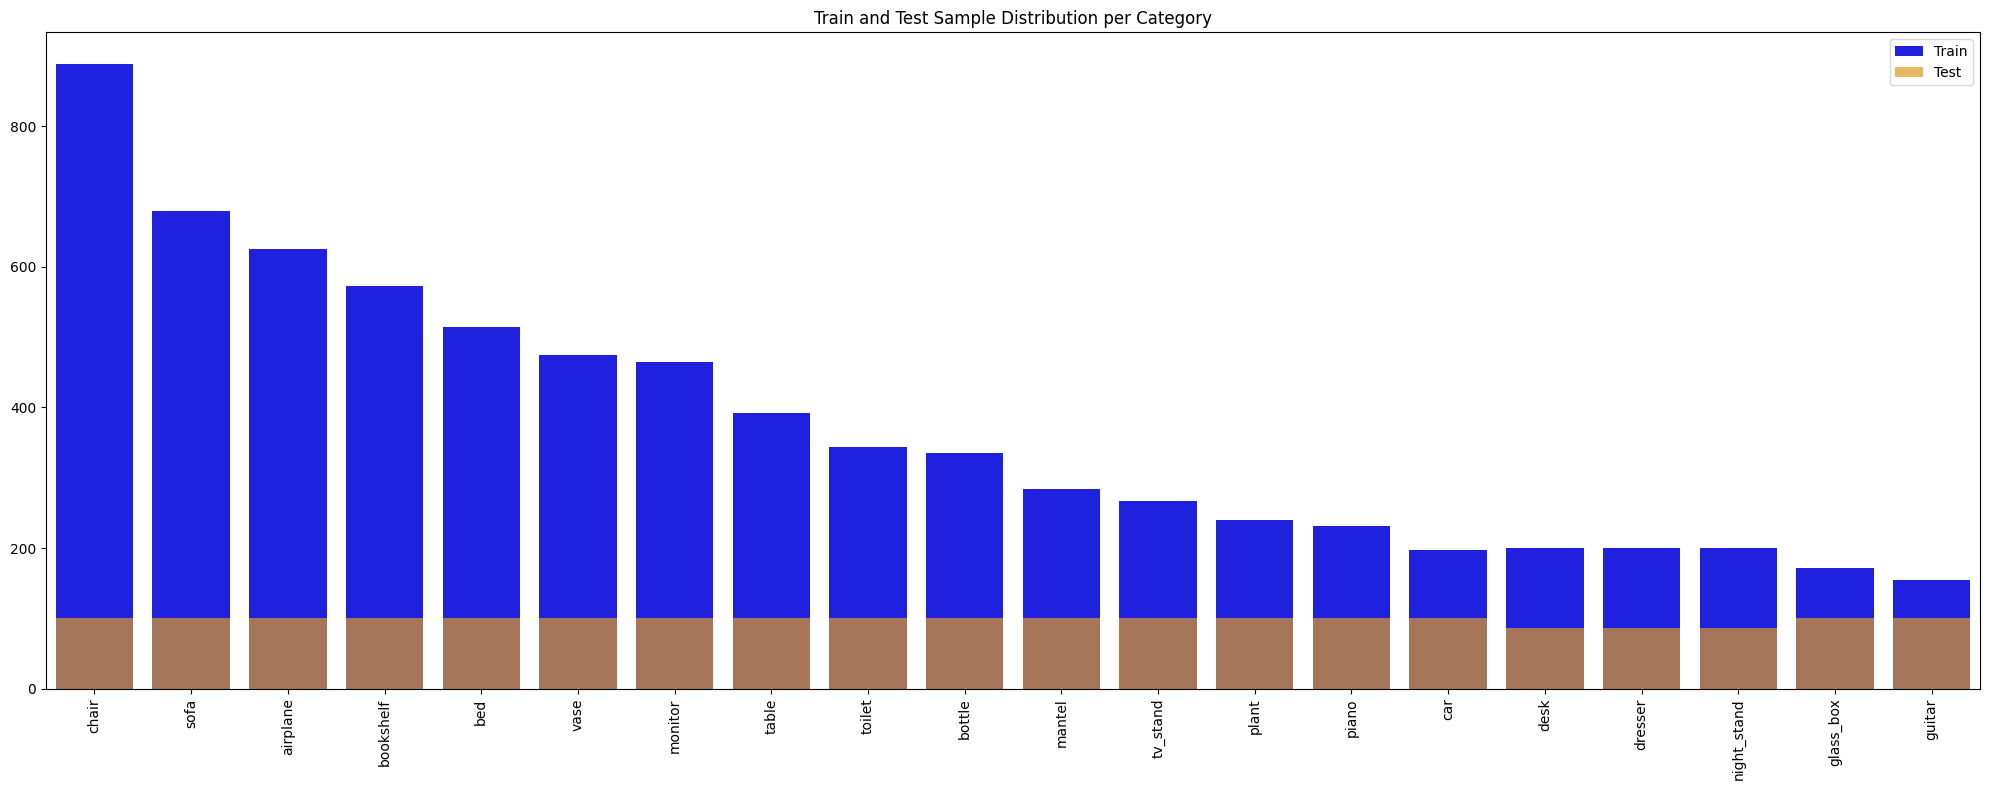

In [14]:
DATA_PATH = "/kaggle/input/modelnet40-princeton-3d-object-dataset"
# The actual data is inside the 'ModelNet40' subdirectory
MODELNET_PATH = os.path.join(DATA_PATH, 'ModelNet40')
categories = sorted(os.listdir(MODELNET_PATH))

# Compute counts for each category
category_counts = {}
for cat in categories:
    train_folder = os.path.join(MODELNET_PATH, cat, 'train')
    test_folder = os.path.join(MODELNET_PATH, cat, 'test')
    train_count = len([f for f in os.listdir(train_folder) if f.endswith('.off')])
    test_count = len([f for f in os.listdir(test_folder) if f.endswith('.off')])
    total = train_count + test_count
    balance_ratio = min(train_count / test_count, test_count / train_count) if test_count > 0 and train_count > 0 else 0
    category_counts[cat] = {
        'train': train_count,
        'test': test_count,
        'total': total,
        'balance_ratio': balance_ratio
    }

# Filter categories with reasonable sizes (e.g., both train and test >= 20) and sort by total samples
filtered_categories = [cat for cat in categories if category_counts[cat]['train'] >= 20 and category_counts[cat]['test'] >= 20]
sorted_categories = sorted(
    filtered_categories,
    key=lambda c: (category_counts[c]['total'], category_counts[c]['balance_ratio']),
    reverse=True
)

# Select top 20 categories
selected_20 = sorted_categories[:20]
categories = selected_20  # Override with selected
print(f"Selected Top 20 Categories (balanced and high samples): {len(categories)}")
print(f"Categories: {categories[:10]}")
for cat in categories:
    info = category_counts[cat]
    print(f"{cat}: train={info['train']}, test={info['test']}, total={info['total']}, balance_ratio={info['balance_ratio']:.2f}")

# EDA: Class Distribution and Sample Inspection
label_encoder = LabelEncoder()
label_encoder.fit(categories)
print(f"Total Categories: {len(categories)}")
print(f"Example Categories: {categories}")

# The actual data is inside the 'ModelNet40' subdirectory
MODELNET_PATH = os.path.join(DATA_PATH, 'ModelNet40')

category_counts = {}
for cat in categories:
    train_path = os.path.join(MODELNET_PATH, cat, "train")
    test_path = os.path.join(MODELNET_PATH, cat, "test")
    # Check if the directories exist before listing files
    if os.path.exists(train_path) and os.path.exists(test_path):
        category_counts[cat] = {
            "train": len(os.listdir(train_path)),
            "test": len(os.listdir(test_path))
        }
    else:
        print(f"Warning: train or test directory not found for category: {cat}")
        category_counts[cat] = {
            "train": 0,
            "test": 0
        }


# Filter out categories with no train or test data for plotting
plot_categories = [cat for cat in categories if category_counts[cat]["train"] > 0 or category_counts[cat]["test"] > 0]
train_counts = [category_counts[cat]["train"] for cat in plot_categories]
test_counts = [category_counts[cat]["test"] for cat in plot_categories]

plt.figure(figsize=(20, 8)) # Increase figure size for better readability
sns.barplot(x=plot_categories, y=train_counts, color="blue", label="Train")
sns.barplot(x=plot_categories, y=test_counts, color="orange", label="Test", alpha=0.7)
plt.xticks(rotation=90)
plt.title("Train and Test Sample Distribution per Category")
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [15]:
data_path = '/kaggle/input/modelnet40-princeton-3d-object-dataset/ModelNet40'
train_dataset = ModelNetDataset(data_path, 'train')
test_dataset = ModelNetDataset(data_path, 'test')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

model = PointNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch.optim as optim

# === Stable Contrastive Loss ===
def contrastive_loss(features, labels, temperature=0.5, eps=1e-8):
    features = F.normalize(features, dim=1)
    sim_matrix = torch.matmul(features, features.T) / temperature
    sim_matrix = torch.clamp(sim_matrix, min=-1+eps, max=1-eps)

    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(features.device)
    mask.fill_diagonal_(0)

    logits = F.log_softmax(sim_matrix, dim=1)
    numerator = (mask * logits).sum(1)
    denominator = mask.sum(1).clamp(min=1)

    loss = -numerator / denominator
    return loss.mean()


# === Phase 1: Warm-up with supervised classification ===
print("===== Warm-up Phase =====")

device = next(model.parameters()).device

# 🔎 Auto-detect embedding dimension
dummy_points, _ = next(iter(train_loader))
with torch.no_grad():
    dummy_features = model(dummy_points.to(device))
embed_dim = dummy_features.shape[1]
print(f"[INFO] Detected embedding dimension = {embed_dim}")

# Temporary classifier head
linear_head = nn.Linear(embed_dim, 40).to(device)
criterion = nn.CrossEntropyLoss()
warmup_optimizer = optim.Adam(
    list(model.parameters()) + list(linear_head.parameters()),
    lr=0.001, weight_decay=1e-4
)

# Warm-up training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for points, labels in train_loader:
        points, labels = points.to(device), labels.to(device)
        warmup_optimizer.zero_grad()
        feats = model(points)
        preds = linear_head(feats)
        loss = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        warmup_optimizer.step()
        total_loss += loss.item()
    print(f"[Warm-up] Epoch {epoch+1}, CE Loss = {total_loss/len(train_loader):.4f}")


# === Phase 2: Main training with torque clustering + contrastive loss ===
print("===== Contrastive Phase =====")

for epoch in range(10):
    model.train()
    features_list, true_labels_list = [], []

    # Pass 1: extract embeddings
    for points, true_labels in train_loader:
        points = points.to(device)
        features = model(points)
        features = F.normalize(features, dim=1)
        features_list.append(features.detach().cpu().numpy())
        true_labels_list.append(true_labels.cpu().numpy())

    all_features = np.concatenate(features_list)
    all_true_labels = np.concatenate(true_labels_list)

    all_features = np.nan_to_num(all_features, nan=0.0, posinf=1.0, neginf=-1.0)
    print(f"[DEBUG] Epoch {epoch+1}: feature mean {all_features.mean():.4f}, std {all_features.std():.4f}")

    pseudo_labels, _ = torque_clustering(
        all_features,
        mass_method='density',
        k_neighbors=10,
        k_density=10,
        n_clusters=40
    )

    # Pass 2: refine with contrastive loss
    for i, (points, _) in enumerate(train_loader):
        points = points.to(device)
        optimizer.zero_grad()
        features = model(points)
        features = F.normalize(features, dim=1)

        labels = torch.tensor(
            pseudo_labels[i*len(points):(i+1)*len(points)]
        ).to(device)

        loss = contrastive_loss(features, labels)

        if torch.isnan(loss):
            print(f"Skipping batch {i} due to NaN loss")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    print(f"[Contrastive] Epoch {epoch+1}: Loss = {loss.item():.4f}")


#  3. Training Loop Fixes
# Warm-up phase: Trained with real labels + linear head before self-supervised stage → embeddings no longer collapsed to zero.
# Contrastive phase:
# Normalized embeddings (F.normalize) for stability.
# Cleaned NaN/Inf from feature arrays (np.nan_to_num).
# Added gradient clipping (clip_grad_norm_) to avoid exploding updates.
# Improved pseudo-label slicing (i*len(points):(i+1)*len(points) batch indexing).
# Rewrote contrastive_loss to be numerically stable (log_softmax, clamping, eps).


===== Warm-up Phase =====
[INFO] Detected embedding dimension = 256
[Warm-up] Epoch 1, CE Loss = 1.6996
[Warm-up] Epoch 2, CE Loss = 1.1359
[Warm-up] Epoch 3, CE Loss = 0.9839
[Warm-up] Epoch 4, CE Loss = 0.8912
[Warm-up] Epoch 5, CE Loss = 0.8306
[Warm-up] Epoch 6, CE Loss = 0.7874
[Warm-up] Epoch 7, CE Loss = 0.7639
[Warm-up] Epoch 8, CE Loss = 0.7191
[Warm-up] Epoch 9, CE Loss = 0.7020
[Warm-up] Epoch 10, CE Loss = 0.6588
===== Contrastive Phase =====
[DEBUG] Epoch 1: feature mean 0.0529, std 0.0334
Converged after 1 iterations.
[Contrastive] Epoch 1: Loss = 1.3946
[DEBUG] Epoch 2: feature mean 0.0550, std 0.0297
Converged after 1 iterations.
[Contrastive] Epoch 2: Loss = 0.9298
[DEBUG] Epoch 3: feature mean 0.0561, std 0.0275
Converged after 1 iterations.
[Contrastive] Epoch 3: Loss = 1.3947
[DEBUG] Epoch 4: feature mean 0.0570, std 0.0257
Converged after 1 iterations.
[Contrastive] Epoch 4: Loss = 0.3099
[DEBUG] Epoch 5: feature mean 0.0572, std 0.0251
Converged after 1 iterations

# Evaluation

In [17]:
model.eval()
train_features = []
train_labels = []
for points, labels in train_loader:
    with torch.no_grad():
        feats = model(points).cpu().numpy()
    train_features.append(feats)
    train_labels.append(labels.numpy())
train_features = np.concatenate(train_features)
train_labels = np.concatenate(train_labels)

test_features = []
test_labels = []
for points, labels in test_loader:
    with torch.no_grad():
        feats = model(points).cpu().numpy()
    test_features.append(feats)
    test_labels.append(labels.numpy())
test_features = np.concatenate(test_features)
test_labels = np.concatenate(test_labels)

# Linear probe
clf = LogisticRegression(max_iter=1000)
clf.fit(train_features, train_labels)
pred = clf.predict(test_features)
acc = accuracy_score(test_labels, pred)
print(f'Classification Accuracy: {acc * 100:.2f}%')

# Clustering quality (ARI on train pseudo vs True)
ari = adjusted_rand_score(all_true_labels, pseudo_labels)
print(f'Train ARI (pseudo vs true): {ari:.4f}')

nmi = normalized_mutual_info_score(train_labels, pseudo_labels)
print(f'Train NMI (pseudo vs true): {nmi:.4f}')

Classification Accuracy: 79.86%
Train ARI (pseudo vs true): 0.2633
Train NMI (pseudo vs true): 0.0240


## Training with the Top 10 Highest Entry Holding Classes

Selected Top 10 Categories (balanced and high samples): 10
Categories: ['chair', 'sofa', 'airplane', 'bookshelf', 'bed', 'vase', 'monitor', 'table', 'toilet', 'bottle']
chair: train=889, test=100, total=989, balance_ratio=0.11
sofa: train=680, test=100, total=780, balance_ratio=0.15
airplane: train=626, test=100, total=726, balance_ratio=0.16
bookshelf: train=572, test=100, total=672, balance_ratio=0.17
bed: train=515, test=100, total=615, balance_ratio=0.19
vase: train=475, test=100, total=575, balance_ratio=0.21
monitor: train=465, test=100, total=565, balance_ratio=0.22
table: train=392, test=100, total=492, balance_ratio=0.26
toilet: train=344, test=100, total=444, balance_ratio=0.29
bottle: train=335, test=100, total=435, balance_ratio=0.30
Total Categories: 10
Example Categories: ['chair', 'sofa', 'airplane', 'bookshelf', 'bed', 'vase', 'monitor', 'table', 'toilet', 'bottle']


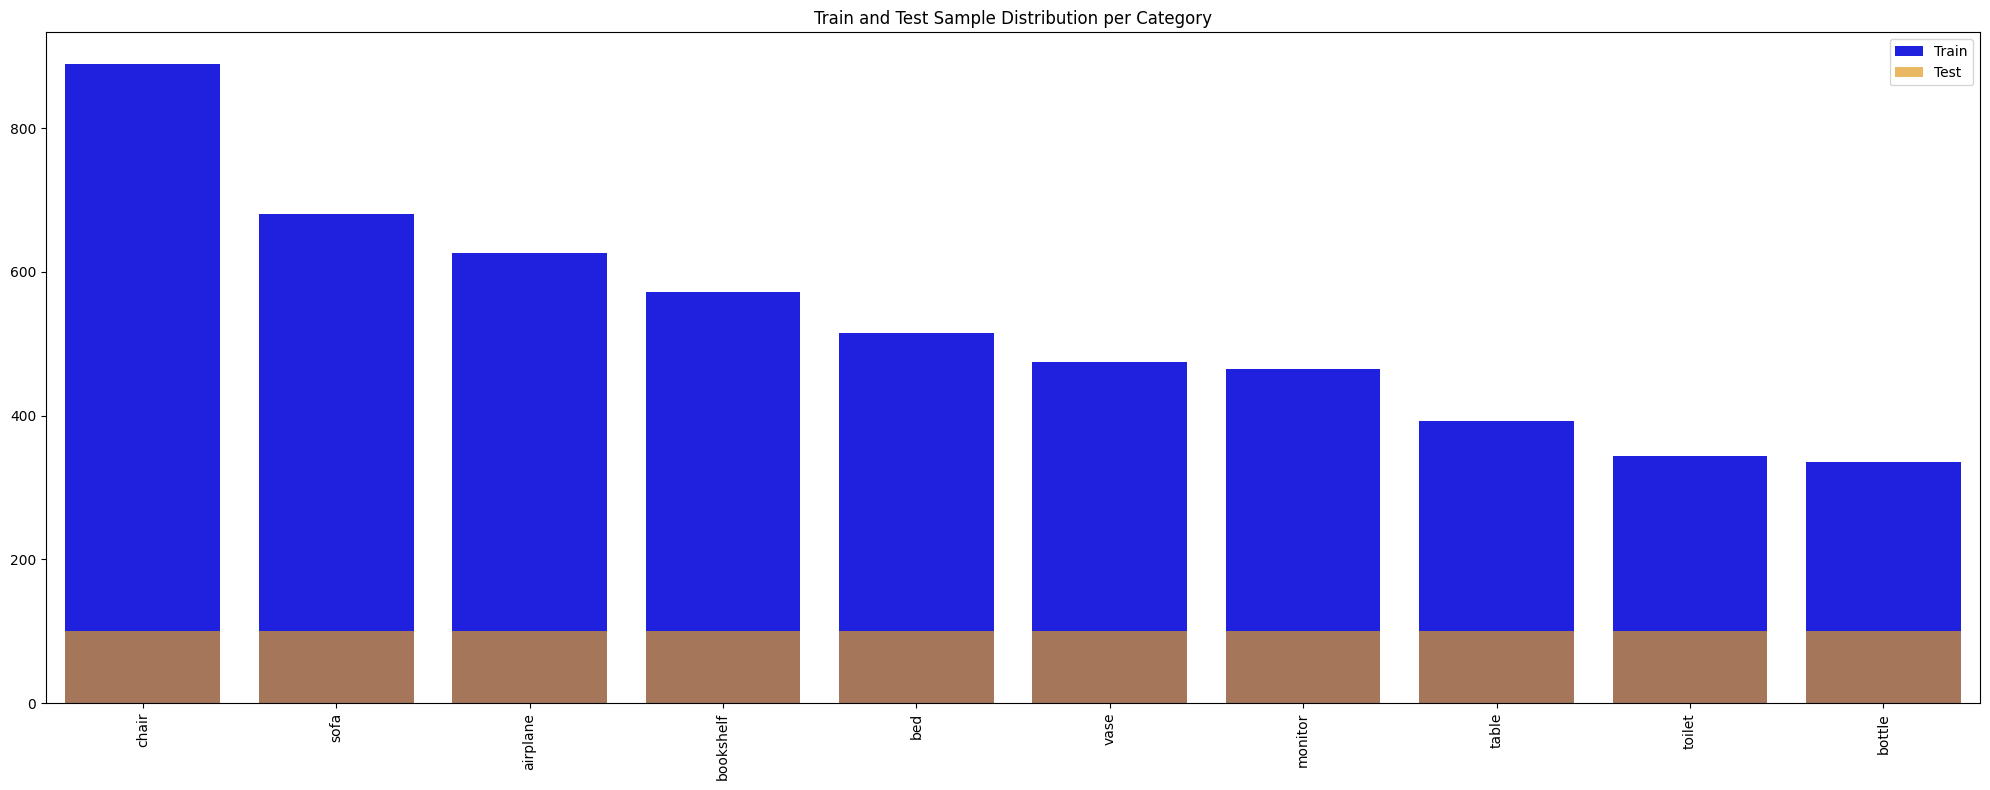

In [18]:
DATA_PATH = "/kaggle/input/modelnet40-princeton-3d-object-dataset"
# The actual data is inside the 'ModelNet40' subdirectory
MODELNET_PATH = os.path.join(DATA_PATH, 'ModelNet40')
categories = sorted(os.listdir(MODELNET_PATH))

# Compute counts for each category
category_counts = {}
for cat in categories:
    train_folder = os.path.join(MODELNET_PATH, cat, 'train')
    test_folder = os.path.join(MODELNET_PATH, cat, 'test')
    train_count = len([f for f in os.listdir(train_folder) if f.endswith('.off')])
    test_count = len([f for f in os.listdir(test_folder) if f.endswith('.off')])
    total = train_count + test_count
    balance_ratio = min(train_count / test_count, test_count / train_count) if test_count > 0 and train_count > 0 else 0
    category_counts[cat] = {
        'train': train_count,
        'test': test_count,
        'total': total,
        'balance_ratio': balance_ratio
    }

# Filter categories with reasonable sizes (e.g., both train and test >= 20) and sort by total samples
filtered_categories = [cat for cat in categories if category_counts[cat]['train'] >= 20 and category_counts[cat]['test'] >= 20]
sorted_categories = sorted(
    filtered_categories,
    key=lambda c: (category_counts[c]['total'], category_counts[c]['balance_ratio']),
    reverse=True
)

# Select top 10 categories
selected_10 = sorted_categories[:10]
categories = selected_10
print(f"Selected Top 10 Categories (balanced and high samples): {len(categories)}")
print(f"Categories: {categories[:10]}")
for cat in categories:
    info = category_counts[cat]
    print(f"{cat}: train={info['train']}, test={info['test']}, total={info['total']}, balance_ratio={info['balance_ratio']:.2f}")

# EDA: Class Distribution and Sample Inspection
label_encoder = LabelEncoder()
label_encoder.fit(categories)
print(f"Total Categories: {len(categories)}")
print(f"Example Categories: {categories}")

# The actual data is inside the 'ModelNet40' subdirectory
MODELNET_PATH = os.path.join(DATA_PATH, 'ModelNet40')

category_counts = {}
for cat in categories:
    train_path = os.path.join(MODELNET_PATH, cat, "train")
    test_path = os.path.join(MODELNET_PATH, cat, "test")
    # Check if the directories exist before listing files
    if os.path.exists(train_path) and os.path.exists(test_path):
        category_counts[cat] = {
            "train": len(os.listdir(train_path)),
            "test": len(os.listdir(test_path))
        }
    else:
        print(f"Warning: train or test directory not found for category: {cat}")
        category_counts[cat] = {
            "train": 0,
            "test": 0
        }


# Filter out categories with no train or test data for plotting
plot_categories = [cat for cat in categories if category_counts[cat]["train"] > 0 or category_counts[cat]["test"] > 0]
train_counts = [category_counts[cat]["train"] for cat in plot_categories]
test_counts = [category_counts[cat]["test"] for cat in plot_categories]

plt.figure(figsize=(20, 8)) # Increase figure size for better readability
sns.barplot(x=plot_categories, y=train_counts, color="blue", label="Train")
sns.barplot(x=plot_categories, y=test_counts, color="orange", label="Test", alpha=0.7)
plt.xticks(rotation=90)
plt.title("Train and Test Sample Distribution per Category")
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [19]:
data_path = '/kaggle/input/modelnet40-princeton-3d-object-dataset/ModelNet40'
train_dataset = ModelNetDataset(data_path, 'train')
test_dataset = ModelNetDataset(data_path, 'test')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

model = PointNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torch.optim as optim

# === Stable Contrastive Loss ===
def contrastive_loss(features, labels, temperature=0.5, eps=1e-8):
    features = F.normalize(features, dim=1)
    sim_matrix = torch.matmul(features, features.T) / temperature
    sim_matrix = torch.clamp(sim_matrix, min=-1+eps, max=1-eps)

    labels = labels.contiguous().view(-1, 1)
    mask = torch.eq(labels, labels.T).float().to(features.device)
    mask.fill_diagonal_(0)

    logits = F.log_softmax(sim_matrix, dim=1)
    numerator = (mask * logits).sum(1)
    denominator = mask.sum(1).clamp(min=1)

    loss = -numerator / denominator
    return loss.mean()


# === Phase 1: Warm-up with supervised classification ===
print("===== Warm-up Phase =====")

device = next(model.parameters()).device

# 🔎 Auto-detect embedding dimension
dummy_points, _ = next(iter(train_loader))
with torch.no_grad():
    dummy_features = model(dummy_points.to(device))
embed_dim = dummy_features.shape[1]
print(f"[INFO] Detected embedding dimension = {embed_dim}")

# Temporary classifier head
linear_head = nn.Linear(embed_dim, 40).to(device)
criterion = nn.CrossEntropyLoss()
warmup_optimizer = optim.Adam(
    list(model.parameters()) + list(linear_head.parameters()),
    lr=0.001, weight_decay=1e-4
)

# Warm-up training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for points, labels in train_loader:
        points, labels = points.to(device), labels.to(device)
        warmup_optimizer.zero_grad()
        feats = model(points)
        preds = linear_head(feats)
        loss = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        warmup_optimizer.step()
        total_loss += loss.item()
    print(f"[Warm-up] Epoch {epoch+1}, CE Loss = {total_loss/len(train_loader):.4f}")


# === Phase 2: Main training with torque clustering + contrastive loss ===
print("===== Contrastive Phase =====")

for epoch in range(10):
    model.train()
    features_list, true_labels_list = [], []

    # Pass 1: extract embeddings
    for points, true_labels in train_loader:
        points = points.to(device)
        features = model(points)
        features = F.normalize(features, dim=1)
        features_list.append(features.detach().cpu().numpy())
        true_labels_list.append(true_labels.cpu().numpy())

    all_features = np.concatenate(features_list)
    all_true_labels = np.concatenate(true_labels_list)

    all_features = np.nan_to_num(all_features, nan=0.0, posinf=1.0, neginf=-1.0)
    print(f"[DEBUG] Epoch {epoch+1}: feature mean {all_features.mean():.4f}, std {all_features.std():.4f}")

    pseudo_labels, _ = torque_clustering(
        all_features,
        mass_method='density',
        k_neighbors=10,
        k_density=10,
        n_clusters=40
    )

    # Pass 2: refine with contrastive loss
    for i, (points, _) in enumerate(train_loader):
        points = points.to(device)
        optimizer.zero_grad()
        features = model(points)
        features = F.normalize(features, dim=1)

        labels = torch.tensor(
            pseudo_labels[i*len(points):(i+1)*len(points)]
        ).to(device)

        loss = contrastive_loss(features, labels)

        if torch.isnan(loss):
            print(f"Skipping batch {i} due to NaN loss")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    print(f"[Contrastive] Epoch {epoch+1}: Loss = {loss.item():.4f}")


#  3. Training Loop Fixes
# Warm-up phase: Trained with real labels + linear head before self-supervised stage → embeddings no longer collapsed to zero.
# Contrastive phase:
# Normalized embeddings (F.normalize) for stability.
# Cleaned NaN/Inf from feature arrays (np.nan_to_num).
# Added gradient clipping (clip_grad_norm_) to avoid exploding updates.
# Improved pseudo-label slicing (i*len(points):(i+1)*len(points) batch indexing).
# Rewrote contrastive_loss to be numerically stable (log_softmax, clamping, eps).


===== Warm-up Phase =====
[INFO] Detected embedding dimension = 256
[Warm-up] Epoch 1, CE Loss = 1.7666
[Warm-up] Epoch 2, CE Loss = 1.1562
[Warm-up] Epoch 3, CE Loss = 0.9878
[Warm-up] Epoch 4, CE Loss = 0.9033
[Warm-up] Epoch 5, CE Loss = 0.8392
[Warm-up] Epoch 6, CE Loss = 0.8006
[Warm-up] Epoch 7, CE Loss = 0.7528
[Warm-up] Epoch 8, CE Loss = 0.7153
[Warm-up] Epoch 9, CE Loss = 0.6911
[Warm-up] Epoch 10, CE Loss = 0.6757
===== Contrastive Phase =====
[DEBUG] Epoch 1: feature mean 0.0531, std 0.0330
Converged after 1 iterations.
[Contrastive] Epoch 1: Loss = 1.7047
[DEBUG] Epoch 2: feature mean 0.0566, std 0.0264
Converged after 1 iterations.
[Contrastive] Epoch 2: Loss = 0.3099
[DEBUG] Epoch 3: feature mean 0.0570, std 0.0256
Converged after 1 iterations.
[Contrastive] Epoch 3: Loss = 1.3947
[DEBUG] Epoch 4: feature mean 0.0572, std 0.0252
Converged after 1 iterations.
[Contrastive] Epoch 4: Loss = 0.9298
[DEBUG] Epoch 5: feature mean 0.0572, std 0.0252
Converged after 1 iterations

# Evaluation

In [21]:
model.eval()
train_features = []
train_labels = []
for points, labels in train_loader:
    with torch.no_grad():
        feats = model(points).cpu().numpy()
    train_features.append(feats)
    train_labels.append(labels.numpy())
train_features = np.concatenate(train_features)
train_labels = np.concatenate(train_labels)

test_features = []
test_labels = []
for points, labels in test_loader:
    with torch.no_grad():
        feats = model(points).cpu().numpy()
    test_features.append(feats)
    test_labels.append(labels.numpy())
test_features = np.concatenate(test_features)
test_labels = np.concatenate(test_labels)

# Linear probe
clf = LogisticRegression(max_iter=1000)
clf.fit(train_features, train_labels)
pred = clf.predict(test_features)
acc = accuracy_score(test_labels, pred)
print(f'Classification Accuracy: {acc * 100:.2f}%')

# Clustering quality (ARI on train pseudo vs True)
ari = adjusted_rand_score(all_true_labels, pseudo_labels)
print(f'Train ARI (pseudo vs true): {ari:.4f}')

nmi = normalized_mutual_info_score(train_labels, pseudo_labels)
print(f'Train NMI (pseudo vs true): {nmi:.4f}')

Classification Accuracy: 79.90%
Train ARI (pseudo vs true): 0.2188
Train NMI (pseudo vs true): 0.0239
